# **Comparison of Linear Model for different datasets.**
We have seen the implementation of linear model on linear regression dataset and explored its limitaions in quadratic datasets by manually defining our model. 

## **Manually creating a model:**
We can manually define a model and create parameters using PyTorch's nn.Module to wrap the parameters and create the forward pass function to pass the model equation.

```python
import torch 
from torch import nn

class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True) 

        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)


    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.weights * x + self.bias

```
### **Note:**
We changed the number of parameters in order to create a polynomial regression equation (specifically quadratic) to better fit the data for non-linear datasets.


## **Pytorch Abstraction for models:**
We can also create a model using PyTorch's abstractions. This takes away from the model's flexibility but makes it scalable and reliable.


In [ ]:
import torch 
from torch import nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(
            in_features=1,
            out_features=1,
            bias=True
        )

    def forward(self, x):
        return self.linear(x)

### **Advantages of the nn.Linear Abstraction:**
* Automated Parameter Calculations: Tensors for weights and biases are initialized dynamically without requring mannual declaration.

* Scalability: The layer is natively engineered for matrix multiplication ($y = xW^T + b$). Scaling from 1 feature to $N$ features requires updating only the in_features parameter rather than re-writing algebraic formulas.

* Clarity: It allows for cleaner, less error-prone code production.

Unfortunately, this removes the flexibility we had with manual declaraion where we could manually include new parameters, change forward pass functions or add a constant to the model. Lets train the models using this Linear Regression code for differnt datatypes once more to revist its limitations.

## **Datasets:**
Here are the datasets we will be testing our model on:

* **Linear Baseline:** [dataset_1_linear.csv](./Resources/dataset_1_linear.csv)  

Consists of uniform data points in a straight line. This will be the best case for our **linear model.**

* **Non-Linear Variant A:** [dataset_2_quadratic_upward.csv](./Resources/dataset_2_quadratic_upward.csv) 

The data is arranged in a quadratic nature.

* **Non-Linear Variant B:** [dataset_3_symmetric_quadratic.csv](./Resources/dataset_3_symmetric_quadratic.csv) 

This dataset consits of full symmetric parabolic curve.

### Visualization:
Lets visualize all three datasets and analyze their geometric properties.

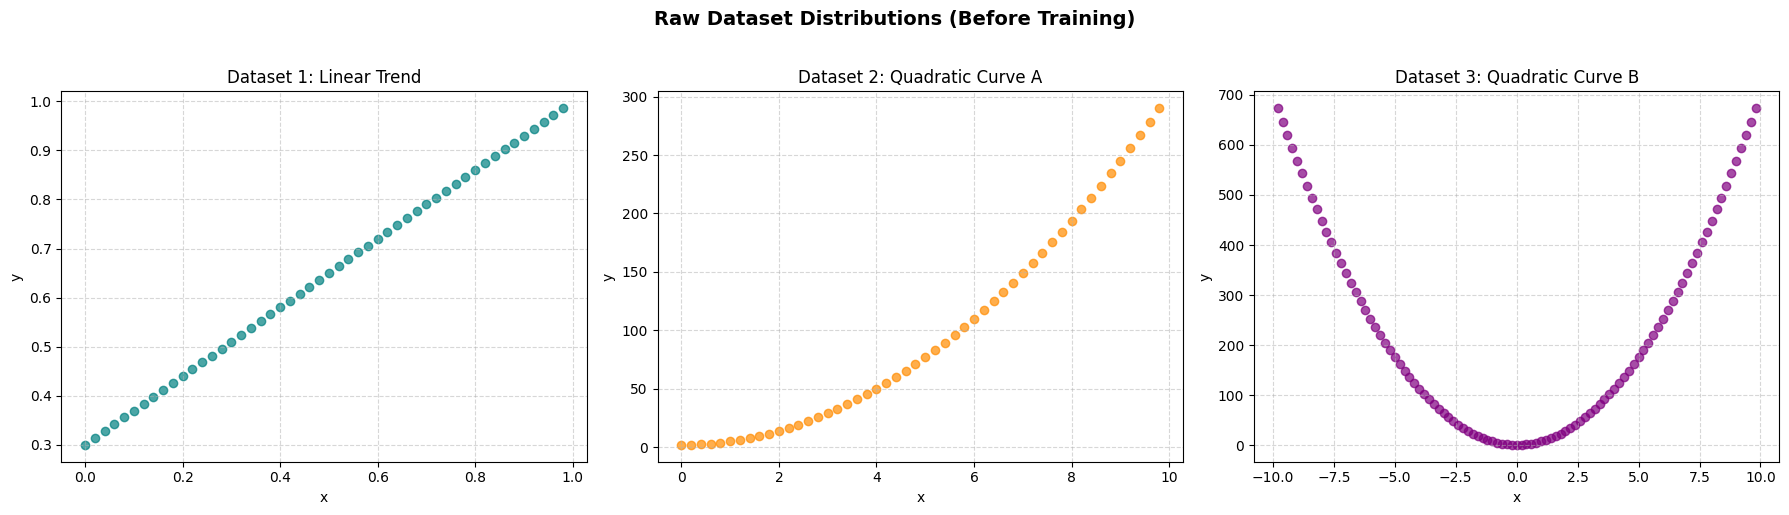

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the raw CSV files from the Resources directory
df1 = pd.read_csv('./Resources/dataset_1_linear.csv')
df2 = pd.read_csv('./Resources/dataset_2_quadratic_upward.csv')
df3 = pd.read_csv('./Resources/dataset_3_symmetric_quadratic.csv')

# Visualize the raw data distributions next to each other 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Dataset 1
axes[0].scatter(df1['x'], df1['y'], color='teal', alpha=0.7)
axes[0].set_title("Dataset 1: Linear Trend")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Dataset 2
axes[1].scatter(df2['x'], df2['y'], color='darkorange', alpha=0.7)
axes[1].set_title("Dataset 2: Quadratic Curve A")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot Dataset 3
axes[2].scatter(df3['x'], df3['y'], color='purple', alpha=0.7)
axes[2].set_title("Dataset 3: Quadratic Curve B")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Raw Dataset Distributions (Before Training)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Data Splitting:**
Lets split each dataset into a **Training Set (80%)**, and a **Testing Set (20%)**. We use **Training Set** to optimize the parameter and use **Testing set** to evalusate model perfomance. 

### **Split Strategy Notes:**
*I have chosen **random split** as opposed to sequential split becuase for non-linear, quadratic distributions, a sequential split could starve the test set of crucial structural sections of the curve. This random split ensures the whole curve is represented in both test and train sets. However,  for datasets that are uniform and linear like in the first case its completely fine to use sequential split too.*
*For the sake of comparing all three datasets, I decided to use the random split*

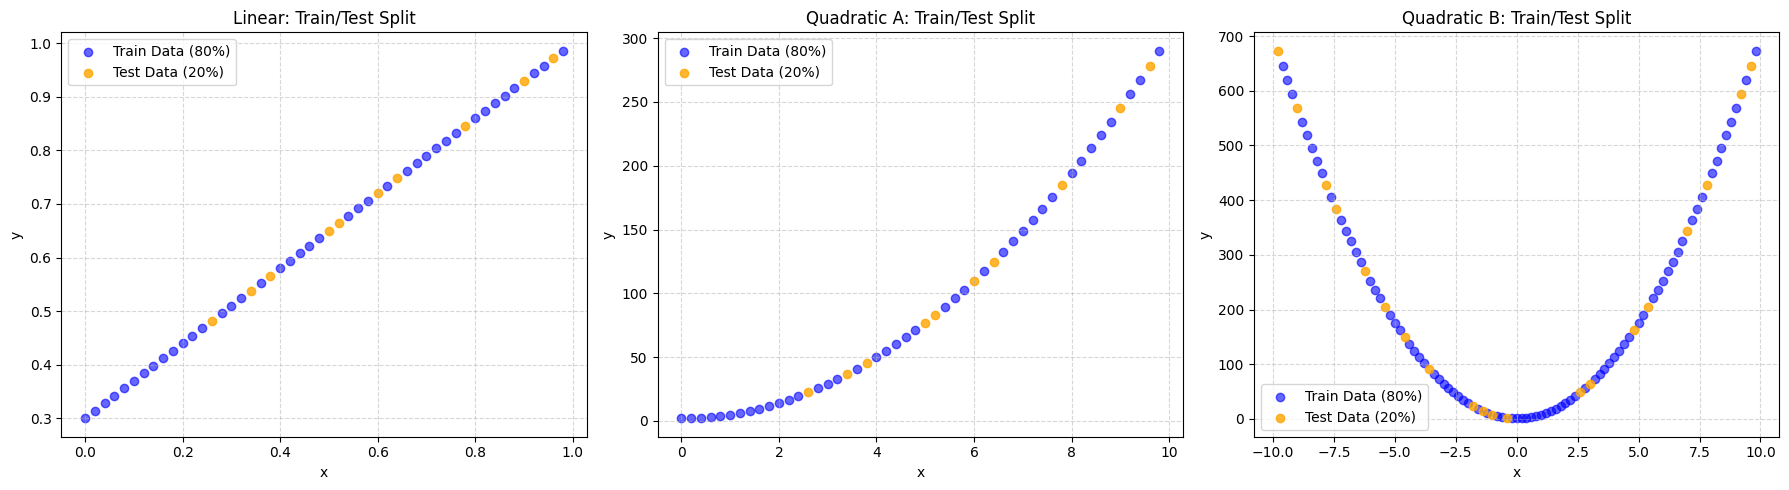

In [ ]:
import torch
from torch import nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Set random seed 
torch.manual_seed(42)

def prepare_and_split_data(filepath):
    df = pd.read_csv(filepath)
    X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(dim=1)
    y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(dim=1)
    
    # 80% Train, 20% Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

# Process all datasets
datasets_paths = {
    'Linear': './Resources/dataset_1_linear.csv',
    'Quadratic A': './Resources/dataset_2_quadratic_upward.csv',
    'Quadratic B': './Resources/dataset_3_symmetric_quadratic.csv'
}

data_splits = {name: prepare_and_split_data(path) for name, path in datasets_paths.items()}

# Plot the Train/Test Splits Side-by-Side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, (X_train, X_test, y_train, y_test)) in enumerate(data_splits.items()):
    axes[i].scatter(X_train.numpy(), y_train.numpy(), color='blue', alpha=0.6, label='Train Data (80%)')
    axes[i].scatter(X_test.numpy(), y_test.numpy(), color='orange', alpha=0.8, label='Test Data (20%)')
    axes[i].set_title(f"{name}: Train/Test Split")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **Model Training**
Lets adjust the parameters to improve the predictions

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1, bias=True)

    def forward(self, x):
        return self.linear(x)


def train_model(X_train, X_test, y_train, y_test, epochs=300, lr=0.01, name=""):
    model = LinearRegressionModel()
    loss_fn = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    model.eval()
    with torch.inference_mode():
        untrained_preds = model(X_test)

    w0 = model.linear.weight.item()  # sanity check: weight before training

    train_loss_history, test_loss_history = [], []
    for epoch in range(epochs):
        model.train()
        preds = model(X_train)
        loss = loss_fn(preds, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.inference_mode():
            test_preds = model(X_test)
            test_loss = loss_fn(test_preds, y_test)

        train_loss_history.append(loss.item())
        test_loss_history.append(test_loss.item())

    model.eval()
    with torch.inference_mode():
        trained_preds = model(X_test)

    w1 = model.linear.weight.item()  # weight after training
    print(f"{name}: weight {w0:.4f} -> {w1:.4f} | bias -> {model.linear.bias.item():.4f} | final train loss {loss.item():.4f}")

    return untrained_preds, trained_preds, train_loss_history, test_loss_history


experiment_results = {}
for name, (X_train, X_test, y_train, y_test) in data_splits.items():
    untrained, trained, train_loss, test_loss = train_model(X_train, X_test, y_train, y_test, name=name)
    experiment_results[name] = {
        'untrained': untrained,
        'trained': trained,
        'train_loss': train_loss,
        'test_loss': test_loss
    }

Linear: weight 0.7645 -> 0.5957 | bias -> 0.3526 | final train loss 0.0010
Quadratic A: weight -0.2343 -> 27.3527 | bias -> -31.4822 | final train loss 501.8989
Quadratic B: weight -0.2191 -> 0.0681 | bias -> 220.1069 | final train loss 39480.1328


## **Loss Curves for the three models.**

The loss curves for the three models are grphically represented as follows:

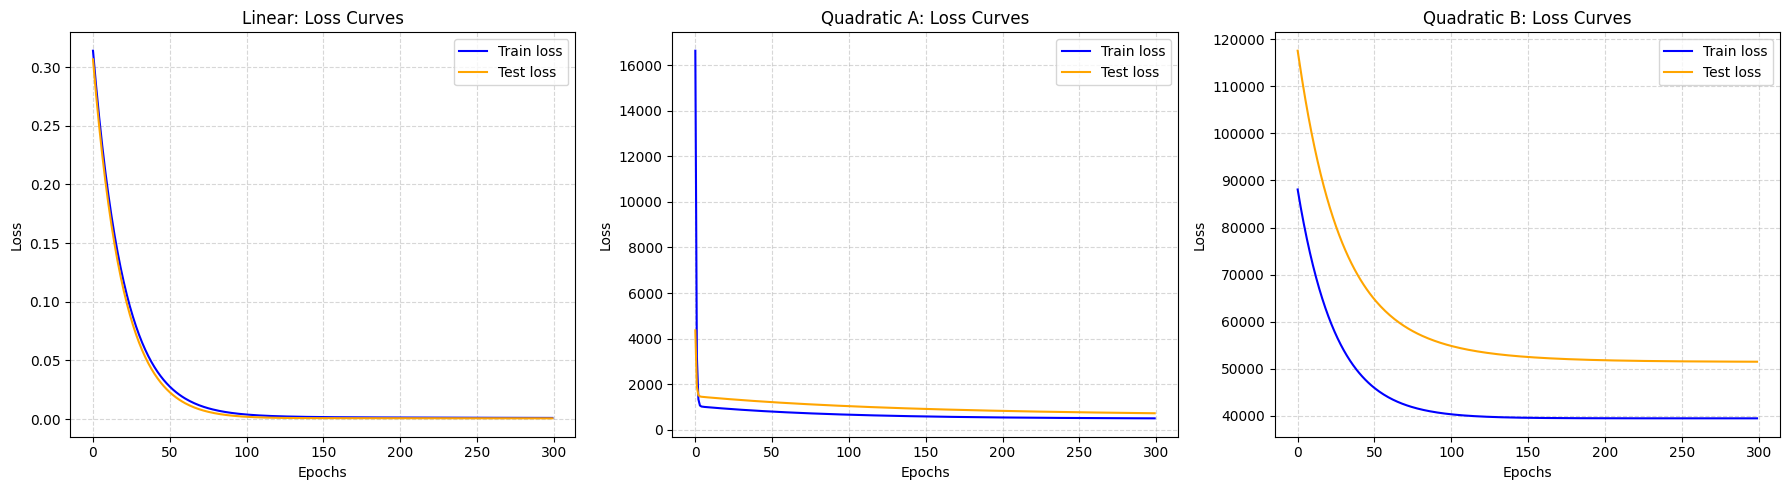

In [ ]:
# Loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, name in enumerate(data_splits.keys()):
    axes[i].plot(experiment_results[name]['train_loss'], label="Train loss", color="blue")
    axes[i].plot(experiment_results[name]['test_loss'], label="Test loss", color="orange")
    axes[i].set_title(f"{name}: Loss Curves")
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



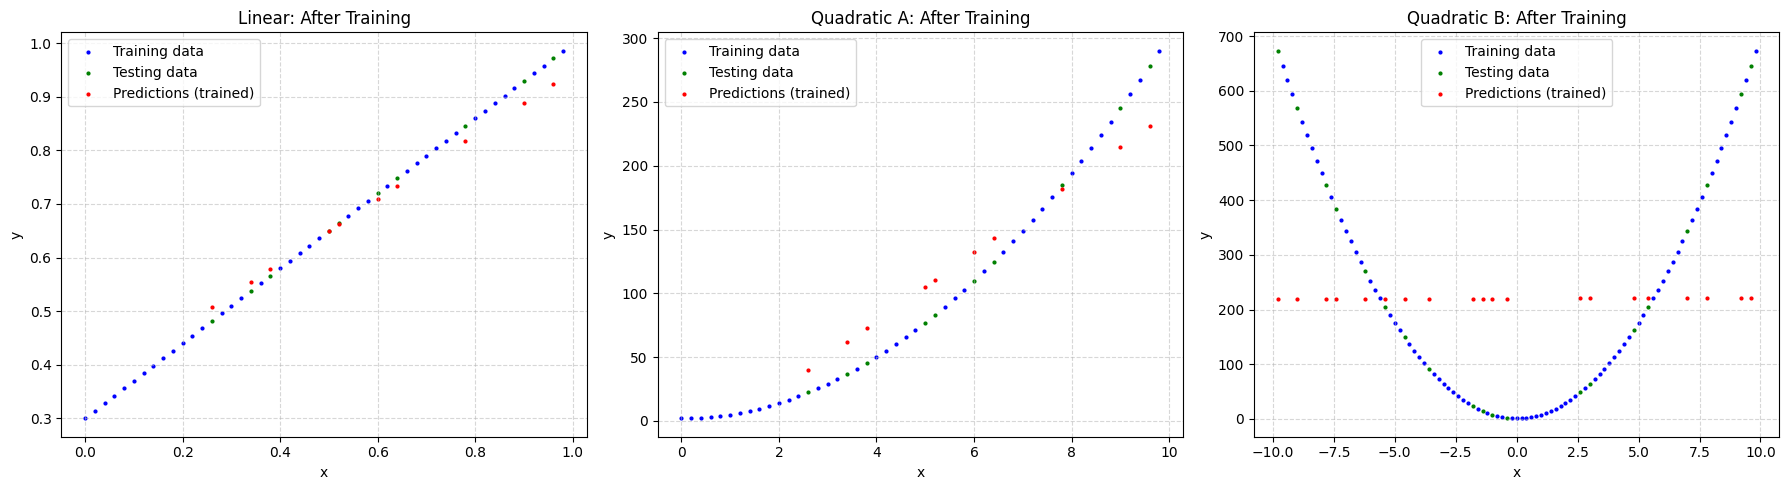

In [ ]:
# Trained fits vs ground truth
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, (X_train, X_test, y_train, y_test)) in enumerate(data_splits.items()):
    trained_preds = experiment_results[name]['trained']
    axes[i].scatter(X_train.numpy(), y_train.numpy(), c="b", s=4, label="Training data")
    axes[i].scatter(X_test.numpy(), y_test.numpy(), c="g", s=4, label="Testing data")
    axes[i].scatter(X_test.numpy(), trained_preds.numpy(), c="r", s=4, label="Predictions (trained)")
    axes[i].set_title(f"{name}: After Training")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")
    axes[i].legend(prop={"size": 10})
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Conclusion**
As we can see the linear model perfectly tuned the parameters for the model to predict the linear data. However for quadratic and parabolic type data, it fails terribly.